# import

In [35]:
import pandas as pd
import numpy as np
import warnings

# 경고 메시지 끄기 (깔끔한 출력을 위해)
warnings.filterwarnings('ignore')


# 데이터 로드 

In [36]:
train_path = r"..\datasets\train.csv"
test_path  = r"..\datasets\test.csv"

try:
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    print(f"학습 세트: {train.shape}")
    print(f"테스트 세트: {test.shape}")
except FileNotFoundError:
    print("❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요.")


학습 세트: (748, 46)
테스트 세트: (814, 45)


# 데이터 통합

정석은 학습 세트와 테스트 세트를 먼저 분할한 후 전처리를 진행하지만, 

단순 모델의 성능을 올리기 위해 학습 세트와 테스트 세트 데이터를 합쳐서 한꺼번에 전처리 후 분할하는 방식 시도

In [37]:
# 나중에 분리하기 위해 꼬리표(Label) 붙이기
train['dataset'] = 'train'
test['dataset'] = 'test'

# 위아래로 합치기
df_all = pd.concat([train, test], ignore_index=True)

print(f"합쳐진 데이터 크기: {df_all.shape}\n")
# 잘 합쳐졌는지 확인
print(df_all['dataset'].value_counts())


합쳐진 데이터 크기: (1562, 47)

dataset
test     814
train    748
Name: count, dtype: int64


# 데이터 전처리 - 변수 제거(1)

[ID] -> 고유 식별자

[generation], [nationality] -> 상수

[school1] -> 카테고리 개수 너무 많고, 변수 의미상 희소 카테고리를 '기타'로 합치기 애매하다고 판단(실제 인적사항이어서)

[interested_company], [incumbents_lecture_scale_reason] -> 서술형, 모델링 이후 과정에서 drop 여부를 다시 고려

+결측치 개수가 전체 데이터의 50% 이상인 12개의 피처 제거

In [38]:
# 1. 수동으로 지정한 삭제 컬럼 (6개)
manual_drop_cols = [
    'ID', 'generation', 'nationality', 'school1', 
    'interested_company', 'incumbents_lecture_scale_reason'
]

# 2. 결측치가 50% 이상인 컬럼 자동 찾기
missing_rate = df_all.isnull().mean()
high_missing_cols = missing_rate[missing_rate >= 0.5].index.tolist()

# 3. 보호해야 할 컬럼 설정
# 주의: 타겟변수 'completed'와 데이터구분 'dataset'은 결측이 많아도 절대 지우면 안 됨!
protect_cols = ['completed', 'dataset']

# 실제로 자동 삭제될 리스트 (보호 대상 제외)
real_high_missing_cols = [c for c in high_missing_cols if c not in protect_cols]

# 4. 삭제 대상 통합 (중복 제거)
# 수동 삭제 대상과 자동 삭제 대상을 합침
final_remove_list = list(set(manual_drop_cols + real_high_missing_cols))

# 삭제 실행
df_all = df_all.drop(columns=final_remove_list)

# 결과 출력
print(f"🗑️ [수동 삭제] 지정된 6개 변수:")
print(f"   -> {manual_drop_cols}")
print("-" * 50)
print(f"🗑️ [자동 삭제] 결측치 50% 이상 ({len(real_high_missing_cols)}개):")
print(f"   -> {sorted(real_high_missing_cols)}")
print("-" * 50)
print(f"✅ 총 삭제된 컬럼 수: {len(final_remove_list)}개")
print(f"📊 현재 남은 컬럼 수: {df_all.shape[1]}")


🗑️ [수동 삭제] 지정된 6개 변수:
   -> ['ID', 'generation', 'nationality', 'school1', 'interested_company', 'incumbents_lecture_scale_reason']
--------------------------------------------------
🗑️ [자동 삭제] 결측치 50% 이상 (12개):
   -> ['class2', 'class3', 'class4', 'contest_award', 'contest_participation', 'idea_contest', 'previous_class_3', 'previous_class_4', 'previous_class_5', 'previous_class_6', 'previous_class_7', 'previous_class_8']
--------------------------------------------------
✅ 총 삭제된 컬럼 수: 18개
📊 현재 남은 컬럼 수: 29


# 데이터 전처리 - 결측치/이상치 처리(2)

수치형 변수 결측치/이상치 처리

[completed_semester] 

-> 중앙값으로 대체 후 데이터 타입을 연속형에서 정수형으로 변환.

값이 0인 데이터가 하나 있었지만, ‘job’==‘직장인’, ‘major1_1’==‘기타’, ‘school1’==0인 것으로 보아, 대학 진학없이 바로 취직한 특이 케이스로 간주하여 이상치 처리 X

In [39]:
target_col = 'completed_semester'

# 1. 이상치 확인 (20 이상인 값들 미리 보기)
outlier_mask = df_all[target_col] >= 20
outliers = df_all.loc[outlier_mask, target_col].tolist()

print(f"🔍 [확인] 값이 20 이상인 이상치 목록 ({len(outliers)}개):")
print(f"   -> {outliers}")

# 2. 이상치 처리: NaN으로 변경 (그래야 중앙값 계산 등에서 제외됨)
# (0인 값은 정상 데이터이므로 건드리지 않음)
df_all.loc[outlier_mask, target_col] = np.nan

# 3. 중앙값 계산 (학습용 데이터 기준!)
median_val = df_all.loc[df_all['dataset'] == 'train', target_col].median()

# 4. 결측치(NaN)를 중앙값으로 채우기 & 정수 변환
df_all[target_col] = df_all[target_col].fillna(median_val).astype(int)

print("-" * 50)
print(f"✅ '{target_col}' 결측치 및 이상치 처리 완료")
print(f"   - 대체된 중앙값: {median_val}\n")
print(df_all[target_col].describe())


🔍 [확인] 값이 20 이상인 이상치 목록 (3개):
   -> [2020.02, 20241.0, 20241.0]
--------------------------------------------------
✅ 'completed_semester' 결측치 및 이상치 처리 완료
   - 대체된 중앙값: 6.0

count    1562.000000
mean        6.117157
std         1.742479
min         0.000000
25%         5.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: completed_semester, dtype: float64


범주형 변수 결측치/이상치 처리 

[major type]에서 '단일 전공공학 (컴퓨터 공학 제외)'라는 이상치 발견 

In [40]:
# 점검할 변수 리스트 (이진 변수 5인방)
check_targets = [
    'major type', 
    're_registration', 
    'project_type', 
    'incumbents_level', 
    'major_data'
]

print("🔍 [정밀 점검] 이진 변수 값 종류 확인")
print("=" * 60)

for col in check_targets:
    if col in df_all.columns:
        # 고유값 추출 (NaN 포함)
        uni_vals = df_all[col].unique()
        # 값 개수 카운트 (어떤 게 주류이고 어떤 게 이상치인지 파악용)
        val_counts = df_all[col].value_counts(dropna=False)
        
        print(f"📌 [{col}]")
        print(f"   - 고유값 목록 ({len(uni_vals)}개): {uni_vals}")
        print(f"   - 값 분포:\n{val_counts}")
        print("-" * 60)
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

print("점검 완료. 이상한 값이 보이면 매핑 딕셔너리에 추가하거나 전처리 단계에서 수정하세요.")


🔍 [정밀 점검] 이진 변수 값 종류 확인
📌 [major type]
   - 고유값 목록 (4개): ['복수 전공 ( 다중전공, 이중전공 포함 )' '단일 전공' nan '단일 전공공학 (컴퓨터 공학 제외)']
   - 값 분포:
major type
단일 전공                      856
복수 전공 ( 다중전공, 이중전공 포함 )    609
NaN                         96
단일 전공공학 (컴퓨터 공학 제외)          1
Name: count, dtype: int64
------------------------------------------------------------
📌 [re_registration]
   - 고유값 목록 (2개): ['아니요' '예']
   - 값 분포:
re_registration
아니요    1261
예       301
Name: count, dtype: int64
------------------------------------------------------------
📌 [project_type]
   - 고유값 목록 (2개): ['팀' '개인']
   - 값 분포:
project_type
팀     1103
개인     459
Name: count, dtype: int64
------------------------------------------------------------
📌 [incumbents_level]
   - 고유값 목록 (2개): ['시니어 (10년차 ~)' '주니어 (0~3년차)']
   - 값 분포:
incumbents_level
주니어 (0~3년차)     1074
시니어 (10년차 ~)     488
Name: count, dtype: int64
------------------------------------------------------------
📌 [major_data]
   - 고유값 목록 (2개): [False  True]
   - 값 

[major1_1] → ‘Unknown’으로 대체

[major type] → major1_1, major1_2 값이 둘 다 존재한다면 '복수 전공 ( 다중전공, 이중전공 포함 )', 그렇지 않다면 '단일 전공'으로 대체

'단일 전공공학 (컴퓨터 공학 제외)' 이상치를 '단일 전공'으로 대체

[major_field] → ‘Unknown’으로 대체

[major1_2] → ‘없음’으로 대체

In [41]:
# 처리할 범주형 변수들
cat_cols = ['major1_1', 'major1_2', 'major_field', 'major type']

print("📊 [처리 전] 범주형 변수 결측치 개수:")
print(df_all[cat_cols].isnull().sum())


# ---------------------------------------------------------
# (0) [추가] 이상치 선제적 처리 (Cleaning)
# ---------------------------------------------------------
# 이상한 값('단일 전공공학...')을 미리 '단일 전공'으로 고쳐놓습니다.
# 이렇게 하면 아래 함수나 나중에 인코딩할 때 별도 예외처리가 필요 없습니다.
dirty_val = '단일 전공공학 (컴퓨터 공학 제외)'
if dirty_val in df_all['major type'].values:
    df_all['major type'] = df_all['major type'].replace(dirty_val, '단일 전공')
    print(f"✅ 이상치 수정 완료: '{dirty_val}' -> '단일 전공'")


# ---------------------------------------------------------
# (1) major1_1 & major_field: 단순 결측 채우기
# ---------------------------------------------------------
df_all['major1_1'] = df_all['major1_1'].fillna('Unknown')
df_all['major_field'] = df_all['major_field'].fillna('Unknown')


# ---------------------------------------------------------
# (2) major type: 결측치만 채우기 (기존 값 유지!)
# ---------------------------------------------------------
# 이미 값이 있으면 그대로 두고, 비어있는 경우에만 로직 적용
def fill_major_type(row):
    # 이미 값이 있으면 건드리지 않음 (아까 고친 '단일 전공'도 여기서 걸러져서 그대로 유지됨)
    if pd.notna(row['major type']):
        return row['major type']
    
    # 값이 비어있을 때만 추론:
    # major1_2가 있으면(값이 있고 '없음'이 아니면) -> 복수 전공으로 추정
    if pd.notna(row['major1_2']) and row['major1_2'] != '없음':
        return '복수 전공 ( 다중전공, 이중전공 포함 )' # (원래 값 유지)
    else:
        return '단일 전공'

df_all['major type'] = df_all.apply(fill_major_type, axis=1)


# ---------------------------------------------------------
# (3) major1_2: 마지막으로 채우기
# ---------------------------------------------------------
# 위에서 major type 채울 때 major1_2 값을 참고했으므로, 이제 안전하게 '없음'으로 채움
df_all['major1_2'] = df_all['major1_2'].fillna('없음')


print("-" * 50)
print("✅ [처리 후] 범주형 변수 결측치 개수:")
print(df_all[cat_cols].isnull().sum())


📊 [처리 전] 범주형 변수 결측치 개수:
major1_1        93
major1_2       622
major_field     97
major type      96
dtype: int64
✅ 이상치 수정 완료: '단일 전공공학 (컴퓨터 공학 제외)' -> '단일 전공'
--------------------------------------------------
✅ [처리 후] 범주형 변수 결측치 개수:
major1_1       0
major1_2       0
major_field    0
major type     0
dtype: int64


# 데이터 전처리 - 범주형 변수 인코딩(3)

[major type], [re_registration], [project_type], [major_data], [incumbents_level]

-> 이진값(카테고리가 2개)을 가지는 5개의 변수: 레이블 인코딩

In [42]:
# ---------------------------------------------------------
# 이진 변수(Binary) 레이블 인코딩
# ---------------------------------------------------------

binary_mappings = {
    'major type': {
        '단일 전공': 0, 
        '복수 전공 ( 다중전공, 이중전공 포함 )': 1
    },
    're_registration': {'아니요': 0, '예': 1},
    'project_type': {'개인': 0, '팀': 1},
    'incumbents_level': {'주니어 (0~3년차)': 0, '시니어 (10년차 ~)': 1}
}

cols_to_map = ['major type', 're_registration', 'project_type', 'incumbents_level']

for col in cols_to_map:
    # 1. 매핑 전에 딕셔너리에 없는 이상한 값이 있는지 체크
    unique_vals = df_all[col].unique()
    valid_keys = binary_mappings[col].keys()
    
    # 딕셔너리에 없는 값 확인
    unknown_vals = [x for x in unique_vals if x not in valid_keys]
    
    if len(unknown_vals) > 0:
        print(f"🚨 {col}에서 매핑 규칙에 없는 값 발견: {unknown_vals}")
    
    # 2. 매핑 적용
    df_all[col] = df_all[col].map(binary_mappings[col])
    
    # 3. 결측치 안전 처리 (정수 변환)
    if df_all[col].isnull().sum() > 0:
        print(f"⚠️ {col}에 NaN 발생 -> 0으로 채움")
        df_all[col] = df_all[col].fillna(0).astype(int)
    
    # 4. 타입 확실하게 정수로 변환 (위에서 NaN 없을 때도 int로 만들기 위함)
    df_all[col] = df_all[col].astype(int)

print("✅ 레이블 인코딩 완료")


# ---------------------------------------------------------
# major_data (Boolean) 처리
# ---------------------------------------------------------
if 'major_data' in df_all.columns:
    df_all['major_data'] = df_all['major_data'].astype(int)

print("-" * 50)
# 확인 대상에 major_data 포함
check_cols = cols_to_map + ['major_data']
print(df_all[check_cols].head())


✅ 레이블 인코딩 완료
--------------------------------------------------
   major type  re_registration  project_type  incumbents_level  major_data
0           1                0             1                 1           0
1           1                0             1                 0           1
2           0                0             0                 0           0
3           1                0             1                 0           0
4           1                0             1                 0           1


희소 카테고리 통합 필요없는 변수들부터 인코딩

1. 일반 명목형 변수

[class1], [job], [hope_for_group], [desired_career_path], [incumbents_lecture_type]

2. 다중 선택 가능 변수

[desired_job_except_data], [expected_domain]

In [43]:
# ---------------------------------------------------------
# 1. 사전 전처리 (콤마 및 패턴 수정)
# ---------------------------------------------------------

# (1) expected_domain 복구 (기존 로직 유지)
domain_fix_map = {
    'M. 전문, 과학 및 기술 서비스업': 'M. 전문 과학 및 기술 서비스업',
    'R. 예술, 스포츠 및 여가관련 서비스업': 'R. 예술 스포츠 및 여가관련 서비스업',
    'O. 공공 행정, 국방 및 사회보장 행정': 'O. 공공 행정 국방 및 사회보장 행정',
    'N. 사업시설 관리, 사업 지원 및 임대 서비스업': 'N. 사업시설 관리 사업 지원 및 임대 서비스업',
    'S. 협회 및 단체, 수리 및 기타 개인 서비스업': 'S. 협회 및 단체 수리 및 기타 개인 서비스업',
    'D. 전기, 가스, 증기 및 공기 조절 공급업': 'D. 전기 가스 증기 및 공기 조절 공급업', 
    'E. 수도, 하수 및 폐기물 처리, 원료 재생업': 'E. 수도 하수 및 폐기물 처리 원료 재생업',
    'A. 농업, 임업 및 어업': 'A. 농업 임업 및 어업',
    'T. 가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동': 'T. 가구 내 고용활동'
}
if 'expected_domain' in df_all.columns:
    for dirty, clean in domain_fix_map.items():
        df_all['expected_domain'] = df_all['expected_domain'].astype(str).str.replace(dirty, clean, regex=False)

# (2) incumbents_lecture_type 문제 해결 (온, 오프라인 -> 온_오프라인)
# 콤마 때문에 찢어지는 걸 방지하기 위해 콤마를 언더바(_)나 슬래시(/)로 변경
if 'incumbents_lecture_type' in df_all.columns:
    df_all['incumbents_lecture_type'] = df_all['incumbents_lecture_type'].str.replace('온, 오프라인', '온_오프라인', regex=False)


# ---------------------------------------------------------
# 2. 인코딩 실행 (공백 트림 기능 추가)
# ---------------------------------------------------------
target_cols = [
    'class1', 'job', 'hope_for_group', 'desired_career_path', 'incumbents_lecture_type', 
    'desired_job_except_data', 'expected_domain'
]

print(f"🚀 인코딩 시작 (대상 {len(target_cols)}개)")
print("=" * 60)

for col in target_cols:
    if col not in df_all.columns: continue

    # (핵심) 콤마 기준으로 찢되, 앞뒤 공백을 제거(strip)하면서 찢어야 함
    # str.get_dummies는 strip 옵션이 없으므로, 수동으로 구현해야 함
    
    # 1. 콤마로 쪼개고(split) -> 공백 제거(strip) -> 다시 합치기(join)
    # 이렇게 하면 "A, B" -> "A,B"로 정리가 됨
    def clean_comma_sep(text):
        if pd.isna(text): return text
        # 콤마로 쪼개서 각각 strip() 하고 다시 콤마로 합침
        return ','.join([x.strip() for x in text.split(',')])
    
    temp_series = df_all[col].astype(str).apply(clean_comma_sep)
    
    # 2. 이제 깨끗해진 상태에서 get_dummies 실행 (★ 수정: dtype=int)
    dummies = temp_series.str.get_dummies(sep=',').astype(int)
    
    dummies = dummies.add_prefix(f"{col}_")
    new_cols = dummies.columns.tolist()
    
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    print(f"📌 [{col}] -> {len(new_cols)}개 생성")
    print(f"   - 변수명: {new_cols}")
    print("-" * 60)

print(f"🎉 최종 컬럼 수: {df_all.shape[1]}")


🚀 인코딩 시작 (대상 7개)
📌 [class1] -> 13개 생성
   - 변수명: ['class1_1', 'class1_11', 'class1_12', 'class1_13', 'class1_14', 'class1_15', 'class1_16', 'class1_2', 'class1_4', 'class1_5', 'class1_6', 'class1_7', 'class1_8']
------------------------------------------------------------
📌 [job] -> 4개 생성
   - 변수명: ['job_대학생', 'job_대학원생', 'job_직장인', 'job_취준생']
------------------------------------------------------------
📌 [hope_for_group] -> 3개 생성
   - 변수명: ['hope_for_group_네. 오프라인으로 참여하고 싶어요', 'hope_for_group_네. 온라인으로 참여하고 싶어요', 'hope_for_group_아니요. 개인적으로 학회 활동을 하고 싶어요']
------------------------------------------------------------
📌 [desired_career_path] -> 5개 생성
   - 변수명: ['desired_career_path_대학원 진학', 'desired_career_path_이직', 'desired_career_path_창업', 'desired_career_path_취업', 'desired_career_path_현재 직장 유지']
------------------------------------------------------------
📌 [incumbents_lecture_type] -> 3개 생성
   - 변수명: ['incumbents_lecture_type_오프라인', 'incumbents_lecture_type_온_오프라인 동시', 'incumbents_lect

희소 카테고리 통합이 필요한 변수들 인코딩

1. 일반 명목형 변수: 데이터 수가 5 이하인 카테고리를 모두 '희소'로 통합 

[what_to_gain], [incumbents_lecture], [incumbents_company_level], [inflow_route], [incumbents_lecture_scale], [whyBDA]

In [44]:
# 점검 대상 (희소 통합 예정 변수들)
check_targets = [
    'what_to_gain', 
    'incumbents_lecture', 
    'incumbents_company_level', 
    'inflow_route', 
    'incumbents_lecture_scale', 
    'whyBDA'
]

print("🔍 [사전 점검] 희소 통합 대상 변수 현황")
print("=" * 60)
pd.set_option('display.max_rows', None)

for col in check_targets:
    if col in df_all.columns:
        print(f"📌 [{col}]")
        
        # 빈도수 확인
        val_counts = df_all[col].value_counts(dropna=False)
        
        print(f"   - 총 카테고리 종류: {len(val_counts)}개")
        print("-" * 30)
        print(val_counts)
        
        # 5개 이하인 것들이 몇 개나 되는지 미리 계산해서 보여줌
        rare_cnt = (val_counts <= 5).sum()
        print("-" * 30)
        print(f"⚠️ [알림] 5개 이하 희소 카테고리: {rare_cnt}개 (통합 대상)")
        print("=" * 60)
        
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

pd.reset_option('display.max_rows')


🔍 [사전 점검] 희소 통합 대상 변수 현황
📌 [what_to_gain]
   - 총 카테고리 종류: 12개
------------------------------
what_to_gain
데이터 분석 역량                                                                          994
프로젝트 경험                                                                            347
공모전 경험                                                                             152
인적 네트워크                                                                             61
기초적인 python, sql 지식 숙지                                                               1
위 항목 전체                                                                              1
공모전과 프로젝트                                                                            1
사실 한가지를 고르기 어렵습니다..ㅠㅠ 학회를 통해 위의 4가지와 협업에 계신 전문가님들에게 유익한 정보를 얻고 소중한 경험을 하고 싶습니다.      1
분석 역량, 공모전 경험, 인적 네트워크                                                               1
개인적으로는 데이터 분석 역량을 키우고, 인적 네트워크를 다져 프로젝트 등 경험과 실적을 쌓을 수 있는 힘을 기르고 또 그렇게 하기 위함         1
취업팁                     

In [45]:
# ---------------------------------------------------------
# 설정
# ---------------------------------------------------------
MIN_FREQ = 5   # 5개 이하는 희소값으로 간주
RARE_LABEL = '희소' # 통합할 이름 (Others 대신 한글로 '희소')

# 대상 변수 6개
rare_targets = [
    'what_to_gain', 
    'incumbents_lecture', 
    'incumbents_company_level', 
    'inflow_route', 
    'incumbents_lecture_scale',
    'whyBDA'
]

print(f"🚀 희소값 통합 및 인코딩 시작 (기준: {MIN_FREQ}개 이하 -> '{RARE_LABEL}')")
print("=" * 60)

for col in rare_targets:
    if col not in df_all.columns:
        print(f"⚠️ {col} 없음 - 스킵")
        continue
    
    # 1. 빈도수 계산
    # (단일 선택이므로 그냥 value_counts 쓰면 됨)
    val_counts = df_all[col].value_counts()
    
    # 2. 희소값 식별 (5개 이하)
    rare_vals = val_counts[val_counts <= MIN_FREQ].index.tolist()
    
    # 3. 희소값 통합 적용
    if len(rare_vals) > 0:
        print(f"📌 [{col}]")
        print(f"   - 희소값 {len(rare_vals)}개 발견 -> '{RARE_LABEL}'로 통합")
        print(f"   - 목록: {rare_vals}")
        
        # replace로 한 번에 변경
        df_all[col] = df_all[col].replace(rare_vals, RARE_LABEL)
    else:
        print(f"📌 [{col}] - 희소값 없음")
        
    # 4. 인코딩 실행 (이제 안심하고 get_dummies)
    # (희소값들은 모두 '희소'라는 하나의 컬럼으로 모이게 됨)
    # (★ 수정: dtype=int)
    dummies = pd.get_dummies(df_all[col], prefix=col, dtype=int)
    
    # 5. 병합 및 원본 삭제
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    # 결과 확인
    new_cols = dummies.columns.tolist()
    print(f"   -> {len(new_cols)}개 변수 생성: {new_cols}")
    print("-" * 60)

print(f"🎉 최종 컬럼 수: {df_all.shape[1]}")


🚀 희소값 통합 및 인코딩 시작 (기준: 5개 이하 -> '희소')
📌 [what_to_gain]
   - 희소값 8개 발견 -> '희소'로 통합
   - 목록: ['기초적인 python, sql 지식 숙지', '위 항목 전체', '공모전과 프로젝트', '사실 한가지를 고르기 어렵습니다..ㅠㅠ 학회를 통해 위의 4가지와 협업에 계신 전문가님들에게 유익한 정보를 얻고 소중한 경험을 하고 싶습니다.', '분석 역량, 공모전 경험, 인적 네트워크', '개인적으로는 데이터 분석 역량을 키우고, 인적 네트워크를 다져 프로젝트 등 경험과 실적을 쌓을 수 있는 힘을 기르고 또 그렇게 하기 위함 ', '취업팁', '위 모두 ..!']
   -> 5개 변수 생성: ['what_to_gain_공모전 경험', 'what_to_gain_데이터 분석 역량', 'what_to_gain_인적 네트워크', 'what_to_gain_프로젝트 경험', 'what_to_gain_희소']
------------------------------------------------------------
📌 [incumbents_lecture]
   - 희소값 8개 발견 -> '희소'로 통합
   - 목록: ['커리어 패스 과정과 직무 강의 둘다 궁금합니다 ', '원동력', '위 항목 전부 다', '위에 3가지 모두 듣고 싶습니다', '위 3개 전부 다', '취업하기 위해 준비했던 각종 데이터 관련 경험들', '커리어패스, 산업 트렌드', '커리어 패스 과정과 직무 강의를 듣고 싶습니다']
   -> 4개 변수 생성: ['incumbents_lecture_산업 트렌드 (예시: ChatGPT로 인한 직무 변화)', 'incumbents_lecture_직무 강의 (예시: 실무 진행 방식 및 직무 준비생을 위한 팁)', 'incumbents_lecture_커리어 패스 과정 (예시: 비전공자/전공자의 취업 준비 및 이직 과정)', 'incumbents_lecture_희소']
--------------------

2. 다중 선택 가능 변수

[desired_certificate], [desired_job]: 데이터 수가 13 이하인 카테고리를 모두 ‘희소’로 통합

[certificate_acquisition]: 데이터 수가 6 이하인 카테고리를 모두 ‘희소’로 통합

[onedayclass_topic]: 데이터 수가 3 이하인 카테고리를 모두 ‘희소’로 통합

[major_field]:  'IT (컴퓨터 공학 포함)', '공학 (컴퓨터 공학 제외)', '자연과학', '자연고학' 를 '이공계'로, '경영학', '사회과학', '인문학', '경제통상학', '교육학', '법학' 를 '인문계'로 통합, 나머지 기존 '예체능', '의약학', 'Unknown'은 그대로 유지.

In [46]:
import re

# 점검 대상
multi_targets = [
    'certificate_acquisition', 
    'desired_certificate', 
    'onedayclass_topic', 
    'desired_job', 
    'major_field'
]

# 괄호 안 콤마 보호 함수 (재사용)
def protect_comma(text):
    if pd.isna(text): return text
    text = str(text)
    return re.sub(r'\([^)]*\)', lambda m: m.group(0).replace(',', '&'), text)

print("🔍 [사전 점검] 다중 선택 변수 알맹이 현황 (콤마 보호 적용)")
print("=" * 60)
pd.set_option('display.max_rows', None)

for col in multi_targets:
    if col in df_all.columns:
        print(f"📌 [{col}]")
        
        # 1. 보호 -> 쪼개기 -> 복원 (안전 분리)
        temp_series = df_all[col].apply(protect_comma).astype(str)
        tokens = temp_series.str.split(',').explode().str.strip()
        tokens = tokens.str.replace('&', ',') # 다시 콤마로 복원해서 확인
        
        # 2. 빈도수 확인
        token_counts = tokens.value_counts()
        
        print(f"   - 총 알맹이 종류: {len(token_counts)}개")
        print("-" * 30)
        print(token_counts)
        
        # 5개 이하인 것들 카운트
        rare_cnt = (token_counts <= 5).sum()
        print("-" * 30)
        print(f"⚠️ [알림] 5개 이하 희소 알맹이: {rare_cnt}개 (통합 대상)")
        print("=" * 60)
        
    else:
        print(f"⚠️ {col} 컬럼이 존재하지 않습니다.")

pd.reset_option('display.max_rows')


🔍 [사전 점검] 다중 선택 변수 알맹이 현황 (콤마 보호 적용)
📌 [certificate_acquisition]
   - 총 알맹이 종류: 33개
------------------------------
certificate_acquisition
없음                                  931
ADsP                                421
SQLD                                301
컴퓨터 활용능력(1,2급)                       99
구글 애널리스트                             51
빅데이터 분석 기사                           38
정보처리기사                               36
사회조사분석사 2급                            5
기타                                    4
컴퓨터활용능력                               3
준비중: ADsP                             2
준비중                                   2
준비중: SQLD                             2
사회조사분석사2급                             2
정보처리기능사                               2
DAsP                                  2
태블로                                   2
OA 자격증                                1
정보처리산업기사                              1
AWS                                   1
MOS EXCEL EXPERT                      1
사조사 2급               

In [47]:
import re

# 공통 함수
def protect_comma(text):
    if pd.isna(text): return text
    text = str(text)
    return re.sub(r'\([^)]*\)', lambda m: m.group(0).replace(',', '&'), text)

# 설정
rare_rules = [
    (['desired_certificate', 'desired_job'], 13), 
    (['certificate_acquisition'], 6),             
    (['onedayclass_topic'], 3)                    
]

print("🚀 [최종 수정] 다중 선택 변수 희소값 통합 (콤마 보호 유지)")
print("=" * 60)

for cols, threshold in rare_rules:
    for col in cols:
        if col not in df_all.columns: continue
        
        # 1. 기준 파악용 (일단 쪼개서 빈도수 계산)
        temp_series = df_all[col].apply(protect_comma).astype(str)
        tokens = temp_series.str.split(',').explode().str.strip()
        # 기준 잡을 때는 &를 ,로 복원해서 확인 (그래야 정확한 이름으로 매칭)
        tokens_restored = tokens.str.replace('&', ',') 
        
        token_counts = tokens_restored.value_counts()
        rare_vals = token_counts[token_counts <= threshold].index.tolist()
        rare_set = set(rare_vals)
        
        print(f"📌 [{col}] 기준: {threshold}개 이하 ({len(rare_vals)}개 통합)")
        
        # 2. 치환 및 보호 상태 유지 (핵심!)
        def replace_rare_and_keep_protected(text):
            if pd.isna(text): return text
            # 들어올 때는 이미 보호된 상태 (예: "컴활(1& 2급), SQLD")
            parts = [t.strip() for t in text.split(',')]
            new_parts = []
            
            for p in parts:
                # 희소값인지 확인할 때는 ,로 복원해서 비교
                original_name = p.replace('&', ',')
                
                if original_name in rare_set:
                    new_parts.append('희소')
                else:
                    # ★ 희소가 아니면, 원래의 보호된 상태(p)를 그대로 쓴다! ★
                    # (즉, &가 들어있는 상태로 유지)
                    new_parts.append(p)
            
            # 다시 콤마로 연결
            return ','.join(sorted(list(set(new_parts))))

        # 3. 적용 (보호된 문자열 반환)
        cleaned_series = temp_series.apply(replace_rare_and_keep_protected)
        
        # 4. 인코딩 (이제 &가 있으니 안 찢어짐!)
        # (★ 수정: dtype=int)
        dummies = cleaned_series.str.get_dummies(sep=',').astype(int)
        dummies = dummies.add_prefix(f"{col}_")
        
        # 5. 컬럼명 복원 (& -> ,)
        # 이제서야 비로소 컬럼명에 있는 &를 콤마로 바꿔줌
        new_cols = [c.replace('&', ',') for c in dummies.columns]
        dummies.columns = new_cols
        
        # 6. 병합
        df_all = pd.concat([df_all, dummies], axis=1)
        df_all.drop(columns=[col], inplace=True)
        
        print(f"   -> {len(new_cols)}개 생성: {new_cols}")
        print("-" * 30)


# ---------------------------------------------------------
# 2. major_field (여긴 괄호 콤마 문제가 없어서 그대로 둠)
# ---------------------------------------------------------
mapping_rule = {
    'IT (컴퓨터 공학 포함)': '이공계',
    '공학 (컴퓨터 공학 제외)': '이공계',
    '자연과학': '이공계',
    '자연고학': '이공계',
    '경영학': '인문계',
    '사회과학': '인문계',
    '인문학': '인문계',
    '경제통상학': '인문계',
    '교육학': '인문계',
    '법학': '인문계'
}

col = 'major_field'
if col in df_all.columns:
    print(f"📌 [{col}] 계열 통합")
    def apply_mapping(text):
        if pd.isna(text): return text
        parts = [t.strip() for t in text.split(',')]
        new_parts = []
        for p in parts:
            if p in mapping_rule:
                new_parts.append(mapping_rule[p])
            else:
                new_parts.append(p)
        return ','.join(sorted(list(set(new_parts))))

    cleaned_series = df_all[col].astype(str).apply(apply_mapping)
    # (★ 수정: dtype=int)
    dummies = cleaned_series.str.get_dummies(sep=',').astype(int)
    dummies = dummies.add_prefix(f"{col}_")
    new_cols = dummies.columns.tolist()
    
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    print(f"   -> {len(new_cols)}개 생성: {new_cols}")

print("=" * 60)
print(f"🎉 처리 완료! 최종 컬럼 수: {df_all.shape[1]}")


🚀 [최종 수정] 다중 선택 변수 희소값 통합 (콤마 보호 유지)
📌 [desired_certificate] 기준: 13개 이하 (49개 통합)
   -> 8개 생성: ['desired_certificate_ADsP', 'desired_certificate_SQLD', 'desired_certificate_구글 애널리스트', 'desired_certificate_빅데이터 분석 기사', 'desired_certificate_정보처리기사', 'desired_certificate_컴퓨터 활용능력(1,2급)', 'desired_certificate_태블로 관련 자격증', 'desired_certificate_희소']
------------------------------
📌 [desired_job] 기준: 13개 이하 (116개 통합)
   -> 11개 생성: ['desired_job_A. 데이터 엔지니어', 'desired_job_B. 데이터 분석가', 'desired_job_C. 데이터 사이언티스트', 'desired_job_D. 인공지능 전문가', 'desired_job_E. 소프트웨어 개발자', 'desired_job_F. UI/UX 디자이너', 'desired_job_G. PM/서비스 기획자', 'desired_job_H. 자연과학계열 연구자', 'desired_job_I. 마케터', 'desired_job_J. MD', 'desired_job_희소']
------------------------------
📌 [certificate_acquisition] 기준: 6개 이하 (26개 통합)
   -> 8개 생성: ['certificate_acquisition_ADsP', 'certificate_acquisition_SQLD', 'certificate_acquisition_구글 애널리스트', 'certificate_acquisition_빅데이터 분석 기사', 'certificate_acquisition_없음', 'certificate_acquisition_정보

[major1_1], [major1_2]

-> 학습 세트만 봤을 때는 카테고리가 둘 다 10개 남짓이었지만 테스트 세트와 합쳐서 보니 300개, 163개로 종류 대폭 증가. 

따라서 '이공계', '상경계', '자연_의약계', '인문_사회계', '예체능계'로 묶고, 이외의 값은 '희소'로 통합. 

이전에 결측치 처리했던 'Unknown'과 '없음'은 그대로 유지. 

In [48]:
# 전공 변수 확인
major_cols = ['major1_1', 'major1_2']

print("🔍 [정밀 점검] 전공 변수 카테고리 분포 확인")
print("=" * 60)
# 카테고리가 많으므로 전체 출력 제한 해제
pd.set_option('display.max_rows', None)

for col in major_cols:
    if col in df_all.columns:
        val_counts = df_all[col].value_counts(dropna=False)
        print(f"📌 [{col}] - 총 종류: {len(val_counts)}개")
        print("-" * 30)
        # 너무 많으면 상위 50개랑 하위 20개만 보는 게 나을 수도 있지만, 일단 요청대로
        print(val_counts) 
        print("=" * 60)
    else:
        print(f"⚠️ {col} 없음")

pd.reset_option('display.max_rows')


🔍 [정밀 점검] 전공 변수 카테고리 분포 확인
📌 [major1_1] - 총 종류: 300개
------------------------------
major1_1
IT(컴퓨터 공학 포함)                                                                              253
경영학                                                                                        178
자연과학                                                                                        97
Unknown                                                                                     93
사회과학                                                                                        57
인문학                                                                                         48
경영학과                                                                                        47
통계학과                                                                                        46
경제통상학                                                                                       36
응용통계학과                                              

In [49]:
# 전공 매핑 함수 (한글 버전, Unknown/없음 보존)
def map_major_category(major_name):
    # 0. 기존 결측치 처리값 보존 (가장 중요!)
    if pd.isna(major_name): return 'Unknown'
    if major_name == 'Unknown': return 'Unknown'
    if major_name == '없음': return '없음'
    
    # 전처리: 괄호/공백 제거, 소문자 변환
    name = str(major_name).replace(' ', '').replace('(', '').replace(')', '').lower()
    
    # 1. 이공계 (IT / 공학 / 데이터 / 통계)
    it_keywords = [
        '컴퓨터', '소프트웨어', 'sw', 'ai', '인공지능', '데이터', 'data', '정보', '전산', 
        '공학', '산업', '시스템', '기계', '전자', '전기', '통신', '보안', '미디어', 
        '디지털', '융합', '통계', '빅데이터', '로봇', '스마트', 'ict', '반도체', '건축', '토목'
    ]
    if any(k in name for k in it_keywords):
        return '이공계'
    
    # 2. 상경계 (경영, 경제)
    biz_keywords = [
        '경영', '경제', '비즈니스', '금융', '회계', '마케팅', '무역', '통상', 
        '관광', '부동산', '컨벤션', '호텔', '세무', '소비자'
    ]
    if any(k in name for k in biz_keywords):
        return '상경계'
    
    # 3. 자연/의약 (자연과학 / 의약학)
    science_keywords = [
        '수학', '물리', '화학', '생물', '과학', '바이오', '의학', '약학', '간호', 
        '보건', '환경', '식품', '영양', '생명', '의류', '조경', '산림', '농업', '수의'
    ]
    if any(k in name for k in science_keywords):
        return '자연_의약계'
    
    # 4. 인문/사회 (인문 / 사회 / 교육 / 법)
    humanity_keywords = [
        '사회', '심리', '정치', '외교', '언어', '문학', '철학', '사학', '영어', '중국어', 
        '일본어', '프랑스', '독일', '러시아', '아시아', '유럽', '국제', '교육', '법학', 
        '행정', '복지', '문화', '인류', '지리', '신문', '방송', '광고', '홍보', '어문', '역사'
    ]
    if any(k in name for k in humanity_keywords):
        return '인문_사회계'
        
    # 5. 예체능
    art_keywords = ['체육', '스포츠', '미술', '디자인', '음악', '작곡', '연기', '영화', '예술', '무용', '바둑']
    if any(k in name for k in art_keywords):
        return '예체능계'
        
    # 6. 그 외 (매칭 안 된 것들) -> 희소
    return '희소'


print("🚀 전공(major1_1, major1_2) 계열화 작업 및 인코딩 시작")
print("=" * 60)


cols_to_map = ['major1_1', 'major1_2']


for col in cols_to_map:
    if col not in df_all.columns: continue
    
    # 1. 키워드 매핑 적용
    df_all[col] = df_all[col].apply(map_major_category)
    
    # 결과 확인
    print(f"📌 [{col}] 계열화 결과:")
    print(df_all[col].value_counts())
    
    # 2. 인코딩 (★ 수정: dtype=int)
    dummies = pd.get_dummies(df_all[col], prefix=col, dtype=int)
    
    # 컬럼명 확인
    new_cols = dummies.columns.tolist()
    
    # 병합
    df_all = pd.concat([df_all, dummies], axis=1)
    df_all.drop(columns=[col], inplace=True)
    
    print(f"   -> {len(new_cols)}개 변수 생성: {new_cols}")
    print("-" * 30)


print(f"🎉 모든 전처리 완료! 최종 컬럼 수: {df_all.shape[1]}")


🚀 전공(major1_1, major1_2) 계열화 작업 및 인코딩 시작
📌 [major1_1] 계열화 결과:
major1_1
이공계        721
상경계        331
자연_의약계     224
인문_사회계     144
Unknown     93
희소          44
예체능계         5
Name: count, dtype: int64
   -> 7개 변수 생성: ['major1_1_Unknown', 'major1_1_상경계', 'major1_1_예체능계', 'major1_1_이공계', 'major1_1_인문_사회계', 'major1_1_자연_의약계', 'major1_1_희소']
------------------------------
📌 [major1_2] 계열화 결과:
major1_2
없음        958
이공계       350
상경계       137
자연_의약계     81
인문_사회계     21
희소         13
예체능계        2
Name: count, dtype: int64
   -> 7개 변수 생성: ['major1_2_상경계', 'major1_2_없음', 'major1_2_예체능계', 'major1_2_이공계', 'major1_2_인문_사회계', 'major1_2_자연_의약계', 'major1_2_희소']
------------------------------
🎉 모든 전처리 완료! 최종 컬럼 수: 154


# EDA

🚀 [EDA] 전처리 완료 데이터 기준 변수 중요도 평가


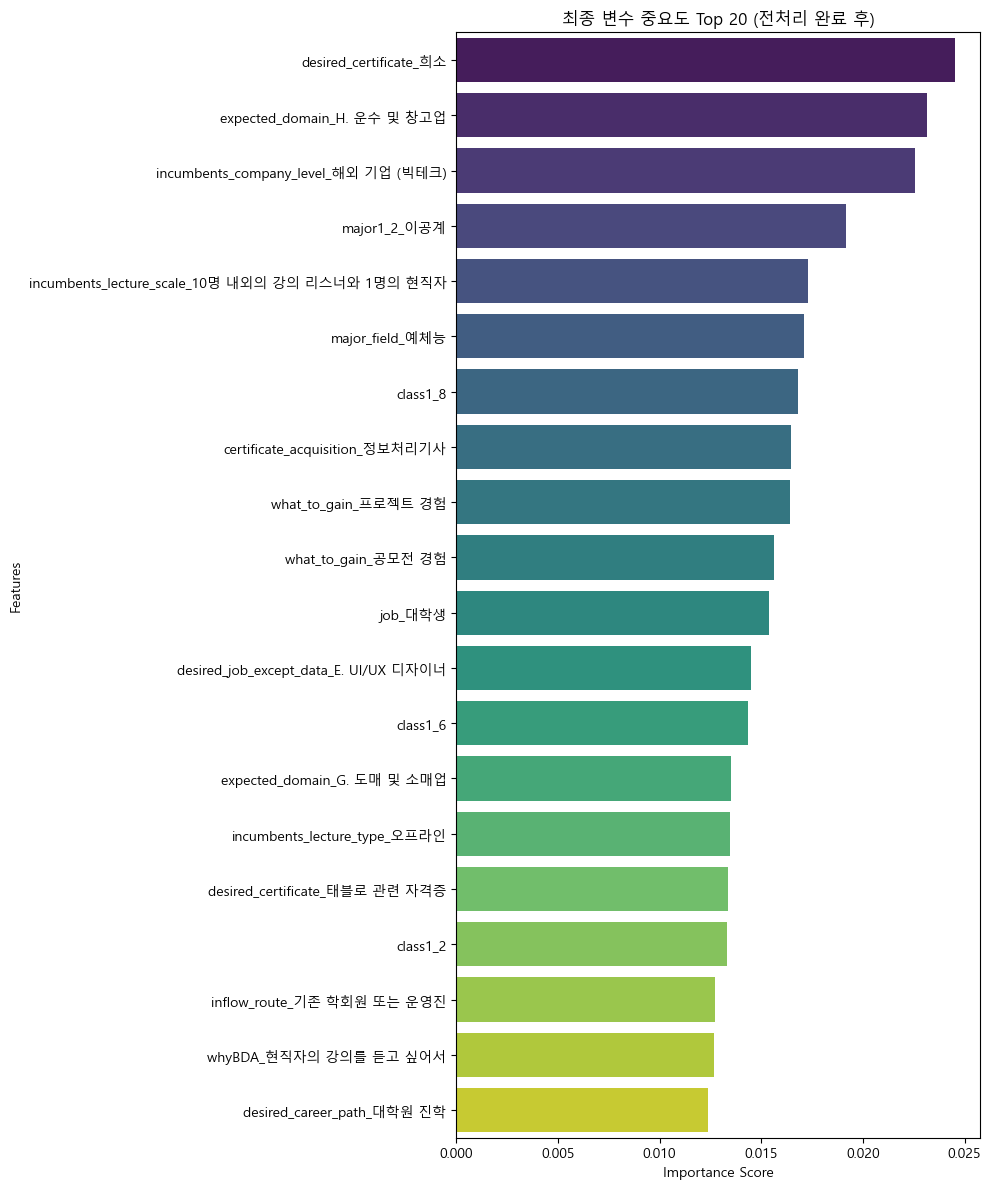

📊 [Top 10 변수]
desired_certificate_희소                              0.024533
expected_domain_H. 운수 및 창고업                         0.023158
incumbents_company_level_해외 기업 (빅테크)                0.022550
major1_2_이공계                                        0.019156
incumbents_lecture_scale_10명 내외의 강의 리스너와 1명의 현직자    0.017312
major_field_예체능                                     0.017122
class1_8                                            0.016789
certificate_acquisition_정보처리기사                      0.016472
what_to_gain_프로젝트 경험                                0.016401
what_to_gain_공모전 경험                                 0.015647
dtype: float32

🚀 [EDA] 주요 변수 상관관계 히트맵


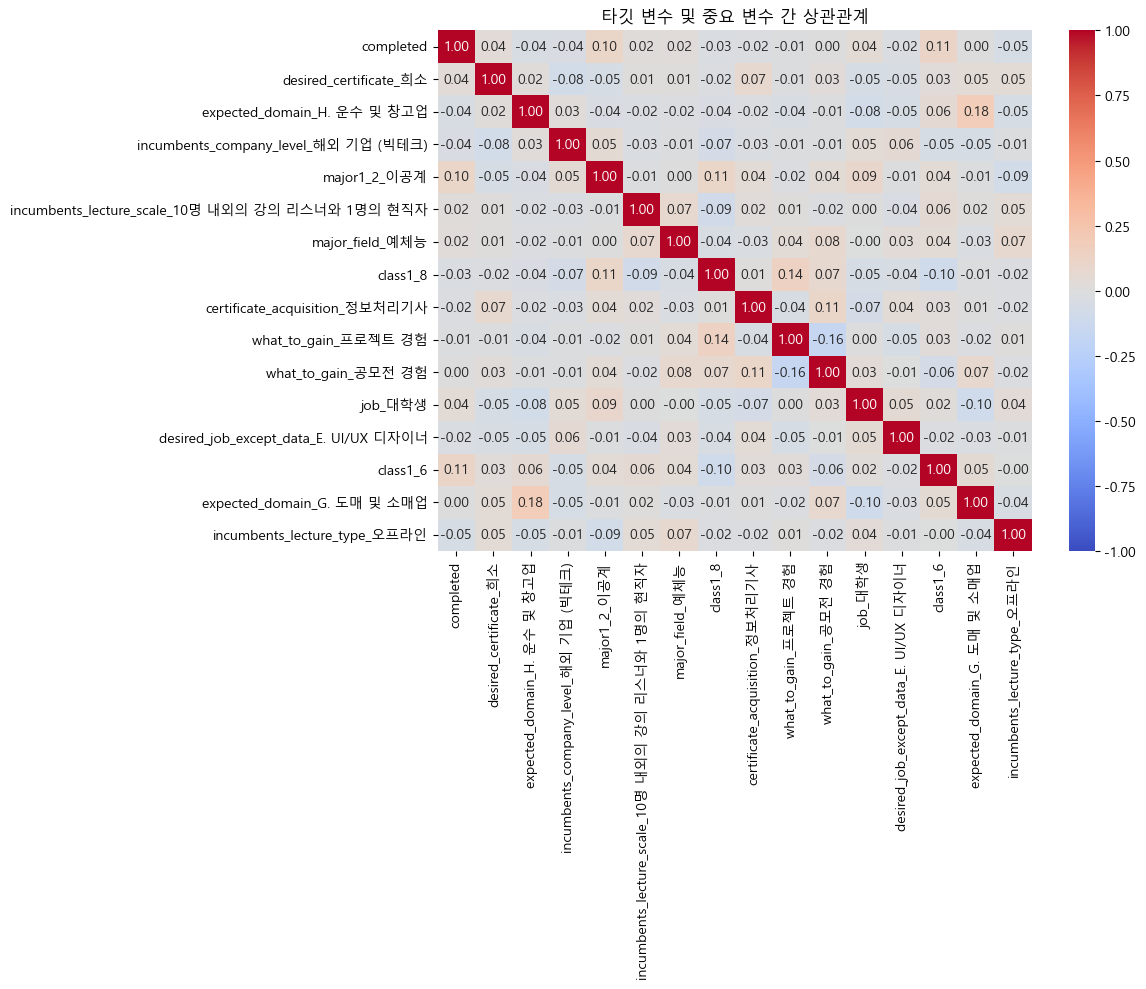

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# =========================================================
# EDA 1. 전처리 완료 변수 중요도 평가 (XGBoost)
# =========================================================
print("🚀 [EDA] 전처리 완료 데이터 기준 변수 중요도 평가")
print("=" * 60)

# 중요도 평가를 위해 잠시 학습 데이터만 분리
eda_train = df_all[df_all['dataset'] == 'train'].drop(columns=['dataset'])
eda_X = eda_train.drop(columns=['completed'])
eda_y = eda_train['completed'].astype(int)

# 모델 학습 (가볍게)
xgb_eda = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_eda.fit(eda_X, eda_y)

# 중요도 추출 및 시각화 (Top 20)
importances = pd.Series(xgb_eda.feature_importances_, index=eda_X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x=importances.head(20), y=importances.head(20).index, palette='viridis')
plt.title("최종 변수 중요도 Top 20 (전처리 완료 후)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

print("📊 [Top 10 변수]")
print(importances.head(10))

# =========================================================
# EDA 2. 주요 변수 간 상관관계 히트맵 (Correlation)
# =========================================================
print("\n🚀 [EDA] 주요 변수 상관관계 히트맵")
print("=" * 60)

# 중요도가 높은 상위 15개 변수 + 타깃변수(completed)만 골라서 히트맵 그리기
top_cols = importances.head(15).index.tolist()
corr_cols = ['completed'] + top_cols

plt.figure(figsize=(12, 10))
corr_mat = eda_train[corr_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("타깃 변수 및 중요 변수 간 상관관계")
plt.tight_layout()
plt.show()


🚀 [심화 EDA] 전처리 완료 데이터 분석 시작

📊 1. 타깃 변수('completed')와의 상관관계 분석


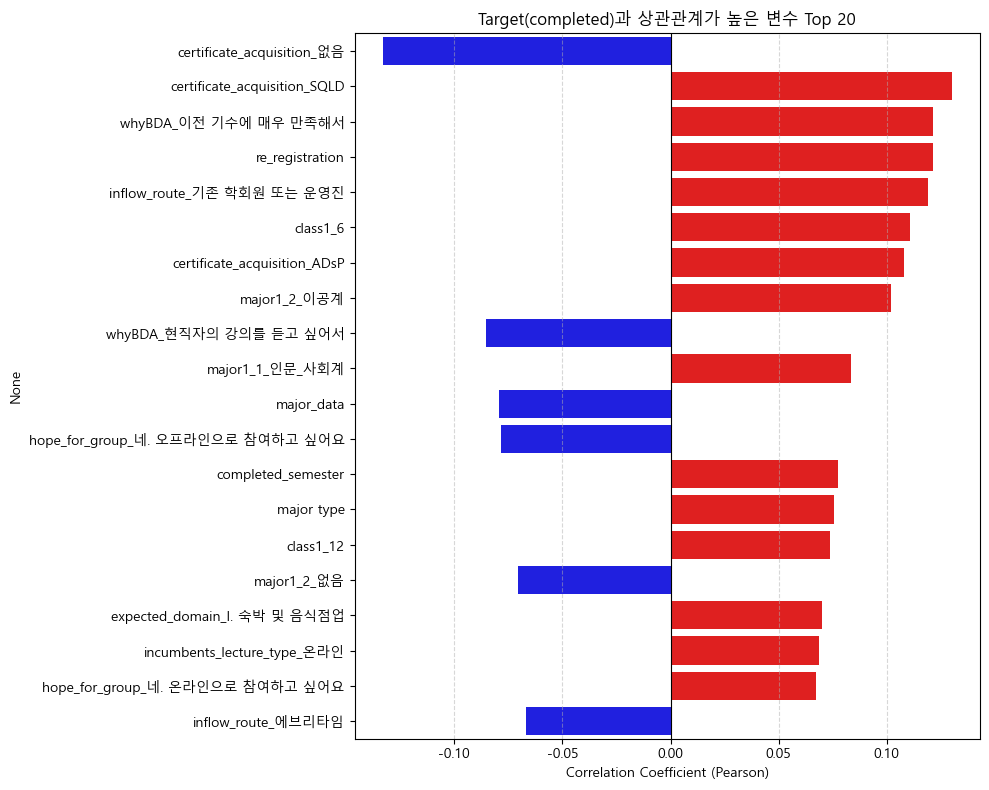

💡 해석: 빨간색 바는 '비례(수료 확률 증가)', 파란색 바는 '반비례(수료 확률 감소)'를 의미합니다.

📊 2. 수료 여부에 따른 주요 변수 평균값 차이
                                미수료(0)     수료(1)  차이(수료-미수료)
certificate_acquisition_없음    0.657143  0.515695   -0.141448
certificate_acquisition_SQLD  0.146667  0.255605    0.108939
whyBDA_이전 기수에 매우 만족해서         0.163810  0.269058    0.105249
re_registration               0.163810  0.269058    0.105249
inflow_route_기존 학회원 또는 운영진    0.169524  0.273543    0.104019
class1_6                      0.076190  0.147982    0.071792
certificate_acquisition_ADsP  0.236190  0.340807    0.104617
major1_2_이공계                  0.160000  0.246637    0.086637
whyBDA_현직자의 강의를 듣고 싶어서        0.089524  0.040359   -0.049165
major1_1_인문_사회계               0.066667  0.116592    0.049925
------------------------------------------------------------
💡 해석: 수료자와 미수료자 간의 평균값 차이가 클수록 중요한 특징입니다.

📊 4. 다중공선성(변수 간 중복) 체크
⚠️ 상관계수 0.9 이상인 '매우 유사한' 변수 쌍 발견 (4개):
   - [inflow_route_기존 학회원 또는 운영진] <---> ['re_registration']
   - [whyBDA_이

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# [사전 준비] 분석용 데이터 정의 (전처리 완료된 Train 데이터)
# ---------------------------------------------------------
eda_train = df_all[df_all['dataset'] == 'train'].drop(columns=['dataset'])

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("🚀 [심화 EDA] 전처리 완료 데이터 분석 시작")
print("=" * 60)

# =========================================================
# 1. 타깃 변수(completed)와의 상관관계 Top 20
# =========================================================
print("\n📊 1. 타깃 변수('completed')와의 상관관계 분석")

# 전체 변수와의 상관계수 계산
corr_with_target = eda_train.corr()['completed'].drop('completed') # 자기 자신 제외

# 상관계수 절대값 기준으로 정렬 (양/음 상관없이 영향력 큰 순서)
top_corr = corr_with_target.abs().sort_values(ascending=False).head(20)
# 실제 부호를 보기 위해 원래 값 가져오기
top_corr_values = corr_with_target[top_corr.index]

plt.figure(figsize=(10, 8))
# 색상으로 양(빨강)/음(파랑) 구분
colors = ['red' if x > 0 else 'blue' for x in top_corr_values.values]
sns.barplot(x=top_corr_values.values, y=top_corr_values.index, palette=colors)
plt.title("Target(completed)과 상관관계가 높은 변수 Top 20")
plt.xlabel("Correlation Coefficient (Pearson)")
plt.axvline(0, color='black', linewidth=0.8) # 0 기준선
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("💡 해석: 빨간색 바는 '비례(수료 확률 증가)', 파란색 바는 '반비례(수료 확률 감소)'를 의미합니다.")

# =========================================================
# 2. 수료자(1) vs 미수료자(0) 그룹별 평균 비교
# =========================================================
print("\n📊 2. 수료 여부에 따른 주요 변수 평균값 차이")

# 상관관계가 높았던 Top 10 변수들만 골라서 비교
compare_cols = top_corr_values.head(10).index.tolist()

group_mean = eda_train.groupby('completed')[compare_cols].mean().T
group_mean.columns = ['미수료(0)', '수료(1)']
group_mean['차이(수료-미수료)'] = group_mean['수료(1)'] - group_mean['미수료(0)']

print(group_mean)
print("-" * 60)
print("💡 해석: 수료자와 미수료자 간의 평균값 차이가 클수록 중요한 특징입니다.")

# =========================================================
# 4. 다중공선성 확인 (상관계수 0.9 이상인 쌍 찾기)
# =========================================================
print("\n📊 4. 다중공선성(변수 간 중복) 체크")

# 전체 상관 행렬 계산
corr_matrix = eda_train.drop(columns=['completed']).corr().abs()

# 상삼각행렬(Upper Triangle)만 선택 (중복 제거)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 상관계수 0.9 이상인 컬럼 찾기
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

if len(to_drop) > 0:
    print(f"⚠️ 상관계수 0.9 이상인 '매우 유사한' 변수 쌍 발견 ({len(to_drop)}개):")
    
    for col in to_drop:
        # 해당 컬럼과 0.9 이상인 짝꿍 찾기
        high_corr_pair = upper.index[upper[col] > 0.9].tolist()
        print(f"   - [{col}] <---> {high_corr_pair}")
        
    print("\n💡 제안: 위 변수들은 서로 정보가 거의 겹치므로, 둘 중 하나를 삭제(Drop)하면 모델 과적합을 줄일 수 있습니다.")
else:
    print("✅ 상관계수 0.9 이상인 중복 변수가 발견되지 않았습니다. (다중공선성 안전)")


# 모델 학습 및 예측

In [52]:
# =========================================================
# [최종 수정] 밸런스 패치 버전 (가중치 완화 + 파라미터 튜닝)
# =========================================================
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import os

# 1. 데이터 분리
print("🚀 데이터셋 분리 및 모델링 준비...")
df_train = df_all[df_all['dataset'] == 'train'].copy()
df_test  = df_all[df_all['dataset'] == 'test'].copy()

df_train.drop(columns=['dataset'], inplace=True)
df_test.drop(columns=['dataset', 'completed'], inplace=True)

X = df_train.drop(columns=['completed'])
y = df_train['completed'].astype(int)
X_test = df_test.copy()

# ---------------------------------------------------------
# [핵심 수정] 가중치 완화 (진정제 투여)
# ---------------------------------------------------------
neg_count = np.sum(y == 0)
pos_count = np.sum(y == 1)
raw_weight = neg_count / pos_count

# ★ 수정 1: 가중치를 70% 수준으로 낮춤 (과민반응 방지)
adjusted_weight = raw_weight * 0.7 

print(f"📊 학습 데이터 분포 - 0(음성): {neg_count}개, 1(양성): {pos_count}개")
print(f"⚖️ 계산된 원본 가중치: {raw_weight:.4f}")
print(f"💊 [적용] 조정된 가중치: {adjusted_weight:.4f} (너무 1로 쏠리는 것 방지)")
print("=" * 60)

# 2. Stratified K-Fold 설정
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_proba = np.zeros(len(y))
test_proba_avg = np.zeros(len(X_test))

# 3. 교차 검증 시작
print(f"🔄 {n_splits}-Fold Cross Validation 시작...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # 모델 정의 (파라미터 미세 조정)
    model = XGBClassifier(
        n_estimators=3000,      # 반복 횟수 넉넉히
        learning_rate=0.01,     # ★ 수정 2: 학습률 낮춤 (0.02 -> 0.01) : 천천히 신중하게 학습
        max_depth=5,            # ★ 수정 3: 깊이 얕게 (6 -> 5) : 과감한 찍기 방지
        
        scale_pos_weight=adjusted_weight, # 조정된 가중치 적용
        
        subsample=0.7,          # ★ 수정 4: 데이터 샘플링 비율 조정
        colsample_bytree=0.7,   # 피처 샘플링 비율 조정
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        early_stopping_rounds=150 # 참을성 조금 더 늘림
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # 예측
    val_p = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = val_p
    test_proba_avg += model.predict_proba(X_test)[:, 1] / n_splits
    
    # F1 확인 (0.5 기준)
    fold_f1 = f1_score(y_val, (val_p >= 0.5).astype(int))
    print(f"   [Fold {fold+1}] Best Iteration: {model.best_iteration} | F1(0.5): {fold_f1:.4f}")

print("=" * 60)

# 4. 임계값 최적화
best_threshold = 0.5
best_f1 = 0

# ★ 수정 5: 탐색 범위를 0.3 이상으로 제한 (너무 낮은 값 방지)
for thr in np.arange(0.3, 0.8, 0.01):
    temp_pred = (oof_proba >= thr).astype(int)
    temp_f1 = f1_score(y, temp_pred)
    if temp_f1 > best_f1:
        best_f1 = temp_f1
        best_threshold = thr

print(f"🎯 최적 임계값: {best_threshold:.2f}")
print(f"📊 CV Optimized F1: {best_f1:.4f}")

# 5. 저장
final_pred = (test_proba_avg >= best_threshold).astype(int)

print("-" * 50)
print(f"📊 최종 예측 분포: {pd.Series(final_pred).value_counts().to_dict()}")

# 저장 로직
origin_test = pd.read_csv(r"..\\datasets\\test.csv")
submission = pd.DataFrame({'ID': origin_test['ID'], 'completed': final_pred})

submit_dir = r"..\\submit"
if not os.path.exists(submit_dir): os.makedirs(submit_dir)

# 파일명 자동 생성
existing_files = [f for f in os.listdir(submit_dir) if f.startswith("submit") and f.endswith(".csv")]
if not existing_files:
    next_index = 1
else:
    indices = []
    for f in existing_files:
        try:
            idx = int(f.replace("submit", "").replace(".csv", ""))
            indices.append(idx)
        except ValueError:
            continue
    next_index = max(indices) + 1 if indices else 1

save_path = os.path.join(submit_dir, f"submit{next_index}.csv")
submission.to_csv(save_path, index=False)
print(f"🎉 저장 완료: {save_path}")


🚀 데이터셋 분리 및 모델링 준비...
📊 학습 데이터 분포 - 0(음성): 525개, 1(양성): 223개
⚖️ 계산된 원본 가중치: 2.3543
💊 [적용] 조정된 가중치: 1.6480 (너무 1로 쏠리는 것 방지)
🔄 5-Fold Cross Validation 시작...
   [Fold 1] Best Iteration: 67 | F1(0.5): 0.0426
   [Fold 2] Best Iteration: 218 | F1(0.5): 0.2295
   [Fold 3] Best Iteration: 0 | F1(0.5): 0.0000
   [Fold 4] Best Iteration: 84 | F1(0.5): 0.0426
   [Fold 5] Best Iteration: 309 | F1(0.5): 0.2414
🎯 최적 임계값: 0.36
📊 CV Optimized F1: 0.4698
--------------------------------------------------
📊 최종 예측 분포: {1: 576, 0: 238}
🎉 저장 완료: ..\\submit\submit14.csv
